In [1]:

from mri_loader import Subject, MRI
from nilearn.glm.first_level import FirstLevelModel

import pandas as pd
import numpy as np

from stats import *




In [2]:
# for meet: maybe event time != process time

subject_ids = set(range(1, 34))
subject_ids -= {1, 3, 13, 22, 32, 33}  # fucked data

subject_ids -= set(range(27, 34))  # exclude SCZ

# subject_ids = list(subject_ids)

run_ids = list(range(1,5))

print(subject_ids, run_ids)

{2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26} [1, 2, 3, 4]


In [3]:

exclude_inflexion = set()


for subject in subject_ids:
    try:
        dataset = Subject(subject, run_ids)

        low_inflexion, high_inflexion = dataset.compute_inflexions()

        if low_inflexion < 0.2 or high_inflexion > 0.8:
            exclude_inflexion.add(subject)
    except:
        exclude_inflexion.add(subject)
        continue



In [4]:
exclude_inflexion

{7, 8, 10, 12, 16, 18, 20, 21, 23, 24, 25, 26}

In [5]:
subject_ids -= exclude_inflexion

subject_ids

{2, 4, 5, 6, 9, 11, 14, 15, 17, 19}

In [6]:
len(subject_ids)

10

In [7]:

global_z_map = {}

contrast_list = [{"+": ["high"], "-": ["low"]},  # high > low
                 {"+": ["undecided"], "-": ["high", "low"]},]  # undecided > high + low

scale = [["25", "35"], ["35", "45"], ["45", "55"], ["55", "65"], ["65", "75"], ["75", "85"], ["85", "95"]]
to_subtract = {"-": ["5", "15"]}

for values in scale:
    contrast_list.append({
        "+": values,
        **to_subtract
    })

for classes in contrast_list:
    name = contrast_name(classes)
    global_z_map[name] = []

global_z_map

{'high > low': [],
 'undecided > high + low': [],
 '25 + 35 > 5 + 15': [],
 '35 + 45 > 5 + 15': [],
 '45 + 55 > 5 + 15': [],
 '55 + 65 > 5 + 15': [],
 '65 + 75 > 5 + 15': [],
 '75 + 85 > 5 + 15': [],
 '85 + 95 > 5 + 15': []}

In [8]:

skipped = []

for subject in subject_ids:

    try:
        dataset = Subject(subject, run_ids)
        dataset.load()

        images, times, labels = dataset.get_data()
        low_inflexion, high_inflexion = dataset.compute_inflexions()
    except Exception as e:
        print("Skipping subject ", subject)
        print(e)
        skipped.append(subject)
        continue

    print(f"{subject=} {low_inflexion=}, {high_inflexion=}")

    labels_class = set(labels)

    events = pd.DataFrame(
        {'onset': times,
         'trial_type': labels,
         'duration': 2.5}
    )

    repetition_time = dataset.repetition_time
    fmri_glm = FirstLevelModel(t_r=repetition_time,
              drift_model='polynomial',
              drift_order=3,
              hrf_model='spm',
              mask_img=dataset.brain_mask,
              smoothing_fwhm=3,
              n_jobs=-1)

    fmri_glm = fmri_glm.fit(images, events)

    design_matrix = fmri_glm.design_matrices_[0]

    contrast_matrix = np.eye(design_matrix.shape[1])
    contrasts = {
        str(column): contrast_matrix[i]
        for i, column in enumerate(design_matrix.columns)
    }

    low_contrast_columns = []
    high_contrast_columns = []
    undecided_contrast_columns = []

    for key, column in contrasts.items():
        try:
            key_numeric = float(key) / 100

            if key_numeric < low_inflexion:
                low_contrast_columns.append(column)

            elif key_numeric > high_inflexion:
                high_contrast_columns.append(column)

            else:
                undecided_contrast_columns.append(column)

        except ValueError:
            continue

    contrasts["low"]       = np.sum(low_contrast_columns, axis=0)
    contrasts["high"]      = np.sum(high_contrast_columns, axis=0)
    contrasts["undecided"] = np.sum(undecided_contrast_columns, axis=0)

    for contrast in contrast_list:

        glm_contrast_vector  = np.sum(contrasts[column] for column in contrast["+"])
        glm_contrast_vector -= np.sum(contrasts[column] for column in contrast["-"])

        z_score = fmri_glm.compute_contrast(glm_contrast_vector, output_type="z_score")
        name = contrast_name(contrast)

        global_z_map[name].append(z_score)




subject=2 low_inflexion=np.float64(0.2698198198198198), high_inflexion=np.float64(0.613063063063063)
subject=4 low_inflexion=np.float64(0.3202702702702702), high_inflexion=np.float64(0.7229729729729729)
subject=5 low_inflexion=np.float64(0.2554054054054054), high_inflexion=np.float64(0.768018018018018)
subject=6 low_inflexion=np.float64(0.2734234234234234), high_inflexion=np.float64(0.7103603603603603)
subject=9 low_inflexion=np.float64(0.2806306306306306), high_inflexion=np.float64(0.3842342342342342)
subject=11 low_inflexion=np.float64(0.2905405405405405), high_inflexion=np.float64(0.7076576576576576)
subject=14 low_inflexion=np.float64(0.20045045045045046), high_inflexion=np.float64(0.7977477477477477)
subject=15 low_inflexion=np.float64(0.25360360360360357), high_inflexion=np.float64(0.6527027027027027)
subject=17 low_inflexion=np.float64(0.2734234234234234), high_inflexion=np.float64(0.7490990990990991)
subject=19 low_inflexion=np.float64(0.24189189189189186), high_inflexion=np.fl

In [9]:
from nilearn.reporting import get_clusters_table
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_stat_map
from brain_map import find_region_names

from nilearn import datasets

import matplotlib.pyplot as plt


In [ ]:
z_map_subjects = set(subject_ids)
z_map_subjects -= set(skipped)

plt.style.use('dark_background')

for contrast_name, images in global_z_map.items():
    for z_score, subject in zip(images, z_map_subjects):

        clean_z, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
        cut_coords_list = [
            (0, 0, 0),
            (10, -20, 30),
            (-15, 10, 45),
        ]

        n_coords = len(cut_coords_list)

        fig, axes = plt.subplots(
            n_coords, 1,
            figsize=(15, 4 * n_coords)
        )

        fig.suptitle(contrast_name, fontweight="bold")

        bg_run = MRI(subject, 1)

        for ax, coords in zip(axes, cut_coords_list):
            plot_stat_map(
                clean_z,
                display_mode='ortho',
                cut_coords=coords,
                axes=ax,
                bg_img=bg_run.background,
                title=f"Ortho @ {coords}",
                colorbar=True
            )

        plt.tight_layout()
        fname = contrast_name.replace(' ', '_').replace('>', 'over')
        plt.savefig(f"graphs/contrasts/sub-{subject}-contrast-{fname}.png")

In [10]:

atlas_name = 'cort-maxprob-thr0-1mm'
harvard = datasets.fetch_atlas_harvard_oxford(atlas_name=atlas_name)

atlas_img = harvard.maps
labels = harvard.labels

regions_activated = {}

for contrast_name, images in global_z_map.items():
    regions_activated[contrast_name] = []

    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
        table = get_clusters_table(
            clean, stat_threshold=threshold, cluster_threshold=5
        )

        pos = [(x,y,z) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        try:
            indexes, regions_names = find_region_names(pos, atlas_img, labels=labels)
        except Exception as e:
            print(e)
            continue

        regions_names = list(set(str(v) for v in regions_names))

        regions_activated[contrast_name].append(regions_names)

        print(f"{contrast_name=}, {regions_names=}")


[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ducat\nilearn_data\fsl

contrast_name='high > low', regions_names=['Temporal Pole', 'Supramarginal Gyrus, posterior division', 'Middle Frontal Gyrus', 'Superior Frontal Gyrus', 'Background', 'Precentral Gyrus', 'Frontal Orbital Cortex', 'Frontal Pole']
contrast_name='high > low', regions_names=['Background', 'Inferior Frontal Gyrus, pars triangularis', 'Frontal Pole']
contrast_name='high > low', regions_names=['Paracingulate Gyrus', 'Middle Frontal Gyrus', 'Superior Frontal Gyrus', 'Background', 'Middle Temporal Gyrus, anterior division', 'Precentral Gyrus', 'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)', 'Frontal Orbital Cortex', 'Subcallosal Cortex', 'Frontal Pole']
contrast_name='high > low', regions_names=['Central Opercular Cortex', 'Frontal Opercular Cortex', 'Middle Frontal Gyrus', 'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)', 'Superior Frontal Gyrus', 'Inferior Frontal Gyrus, pars opercularis', 'Background', 'Inferior Frontal Gyrus, pars triangularis', '

In [11]:
import pandas as pd



In [12]:

regions_activated_np = {}
regions_count = {}

for k, v in regions_activated.items():
    regions_activated_np[k] = np.array(v, dtype=object)

    regions_activated_np[k] = np.concatenate(regions_activated[k])

    regions_count[k] = np.unique_counts(regions_activated_np[k])

regions_count

{'high > low': UniqueCountsResult(values=array(['Background', 'Central Opercular Cortex',
        'Frontal Opercular Cortex', 'Frontal Orbital Cortex',
        'Frontal Pole', 'Inferior Frontal Gyrus, pars opercularis',
        'Inferior Frontal Gyrus, pars triangularis',
        'Inferior Temporal Gyrus, posterior division', 'Insular Cortex',
        'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)',
        'Middle Frontal Gyrus', 'Middle Temporal Gyrus, anterior division',
        'Middle Temporal Gyrus, posterior division', 'Paracingulate Gyrus',
        'Parahippocampal Gyrus, anterior division', 'Postcentral Gyrus',
        'Precentral Gyrus', 'Subcallosal Cortex', 'Superior Frontal Gyrus',
        'Supramarginal Gyrus, posterior division', 'Temporal Pole'],
       dtype='<U67'), counts=array([9, 1, 1, 5, 7, 1, 4, 1, 3, 2, 5, 2, 2, 4, 1, 1, 7, 3, 3, 1, 3])),
 'undecided > high + low': UniqueCountsResult(values=array(['Background', 'Frontal Opercular Cortex', '

In [13]:

df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in regions_activated_np.items()]))

for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(6))


--- high > low ---
high > low
Background                9
Frontal Pole              7
Precentral Gyrus          7
Middle Frontal Gyrus      5
Frontal Orbital Cortex    5
Paracingulate Gyrus       4
Name: count, dtype: int64

--- undecided > high + low ---
undecided > high + low
Background                7
Frontal Pole              7
Temporal Pole             5
Precentral Gyrus          4
Middle Frontal Gyrus      4
Superior Frontal Gyrus    3
Name: count, dtype: int64

--- 25 + 35 > 5 + 15 ---
25 + 35 > 5 + 15
Background                                  9
Superior Frontal Gyrus                      7
Frontal Pole                                6
Parahippocampal Gyrus, anterior division    5
Frontal Orbital Cortex                      5
Temporal Pole                               4
Name: count, dtype: int64

--- 35 + 45 > 5 + 15 ---
35 + 45 > 5 + 15
Background                            9
Cingulate Gyrus, anterior division    7
Frontal Pole                          7
Precentral Gyrus  

In [14]:
summary = pd.DataFrame({
    col.replace(' ', ''): df[col].value_counts()
    for col in df.columns
})

summary = summary.fillna(0)

summary

,high>low,undecided>high+low,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15
Background,9.0,7.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0
Central Opercular Cortex,1.0,0.0,2.0,2.0,2.0,1.0,1.0,2.0,2.0
"Cingulate Gyrus, anterior division",0.0,0.0,3.0,7.0,4.0,3.0,2.0,0.0,1.0
Frontal Medial Cortex,0.0,0.0,2.0,1.0,3.0,0.0,3.0,0.0,0.0
Frontal Opercular Cortex,1.0,2.0,1.0,2.0,0.0,2.0,1.0,1.0,3.0
Frontal Orbital Cortex,5.0,3.0,5.0,2.0,2.0,1.0,3.0,5.0,3.0
Frontal Pole,7.0,7.0,6.0,7.0,9.0,7.0,8.0,8.0,9.0
"Inferior Frontal Gyrus, pars opercularis",1.0,2.0,2.0,2.0,3.0,5.0,5.0,2.0,1.0
"Inferior Frontal Gyrus, pars triangularis",4.0,1.0,1.0,3.0,2.0,0.0,2.0,3.0,3.0
"Inferior Temporal Gyrus, anterior division",0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0


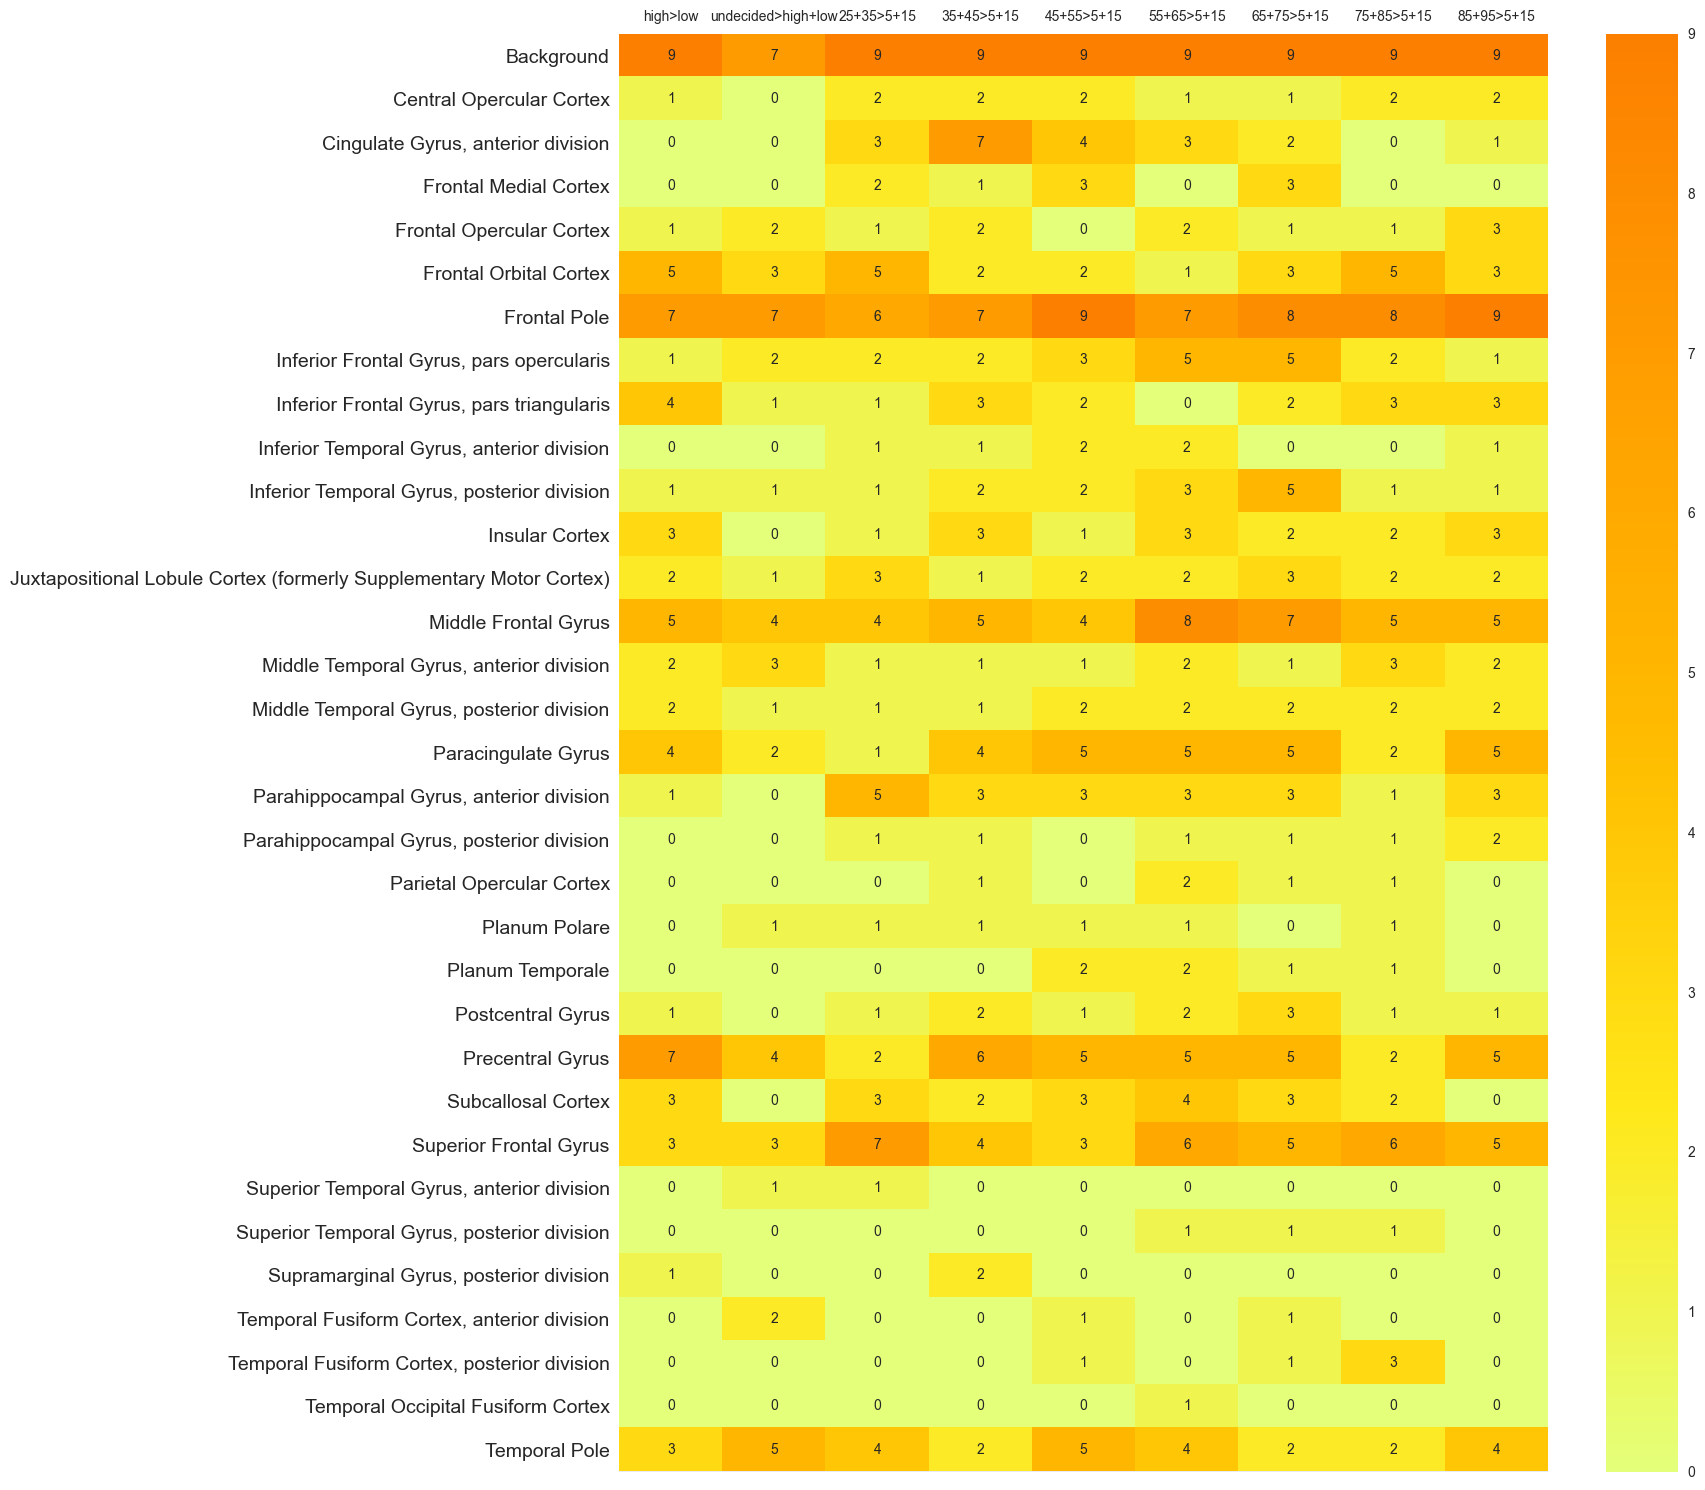

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(summary.columns)))
ax.set_yticks(range(len(summary)))
ax.set_xticklabels(summary.columns, fontsize=10)
ax.set_yticklabels(summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(summary.index)):
    for j in range(len(summary.columns)):
        ax.text(j, i, f'{summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [16]:
summary.style.format("{:.0f}").background_gradient(cmap='Blues')

,high>low,undecided>high+low,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15
Background,9,7,9,9,9,9,9,9,9
Central Opercular Cortex,1,0,2,2,2,1,1,2,2
"Cingulate Gyrus, anterior division",0,0,3,7,4,3,2,0,1
Frontal Medial Cortex,0,0,2,1,3,0,3,0,0
Frontal Opercular Cortex,1,2,1,2,0,2,1,1,3
Frontal Orbital Cortex,5,3,5,2,2,1,3,5,3
Frontal Pole,7,7,6,7,9,7,8,8,9
"Inferior Frontal Gyrus, pars opercularis",1,2,2,2,3,5,5,2,1
"Inferior Frontal Gyrus, pars triangularis",4,1,1,3,2,0,2,3,3
"Inferior Temporal Gyrus, anterior division",0,0,1,1,2,2,0,0,1


In [17]:
for contrast_name, images in global_z_map.items():
    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
        table = get_clusters_table(
            clean, stat_threshold=threshold, cluster_threshold=5
        )

        pos = [(x,y,z) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        print(pos)

        break

    break


[(-36.5, 4.299997806549072, -30.5), (-48.5, 18.699997425079346, -9.5), (32.5, -35.30000114440918, -72.5), (-18.5, -42.500000953674316, -72.5), (-42.5, -38.90000104904175, 5.5), (-21.5, 61.899996280670166, -54.5), (29.5, 40.299996852874756, -54.5), (-6.5, 69.0999960899353, -21.5), (17.5, 40.299996852874756, 53.5), (-15.5, 22.299997329711914, 53.5), (35.5, 54.69999647140503, 23.5), (38.5, 58.2999963760376, 14.5), (-30.5, 11.499997615814209, 32.5), (-45.5, 29.49999713897705, -48.5), (26.5, 11.499997615814209, 2.5), (-54.5, 4.299997806549072, 2.5)]


In [18]:
from lib.mni_to_atlas import AtlasBrowser
import numpy as np

atlas = AtlasBrowser("AAL3")



In [19]:
mni_regions = {}

for contrast_name, images in global_z_map.items():
    mni_regions[contrast_name] = []

    for z_score in images:

        clean, threshold = threshold_stats_img(z_score, alpha=0.001, height_control="fpr", cluster_threshold=5)
        table = get_clusters_table(
            clean, stat_threshold=threshold, cluster_threshold=5
        )

        pos = [np.array([x,y,z]) for (x,y,z) in zip(table['X'], table['Z'], table['Y'])]

        for p in pos:
            projected_coords = atlas.project_to_nearest(p)
            projected_regions = atlas.find_regions(projected_coords)

            mni_regions[contrast_name].append(projected_regions)


In [20]:
mni_regions_concat = {}

for k, v in mni_regions.items():

    reg_list = np.array(v, dtype=object)

    mni_regions_concat[k] = np.concatenate(reg_list)

In [21]:
mni_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in mni_regions_concat.items()]))


In [22]:
mni_summary = pd.DataFrame({
    col.replace(' ', ''): mni_df[col].value_counts()
    for col in mni_df.columns
})

mni_summary = mni_summary.fillna(0)

mni_summary

,high>low,undecided>high+low,25+35>5+15,35+45>5+15,45+55>5+15,55+65>5+15,65+75>5+15,75+85>5+15,85+95>5+15
ACC_pre_L,1.0,1.0,0.0,2.0,2.0,3.0,0.0,0.0,2.0
ACC_pre_R,0.0,2.0,1.0,2.0,1.0,2.0,1.0,0.0,2.0
ACC_sub_L,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
ACC_sub_R,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
ACC_sup_L,0.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
Thal_VL_R,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Thal_VPL_L,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
VTA_L,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Vermis_10,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


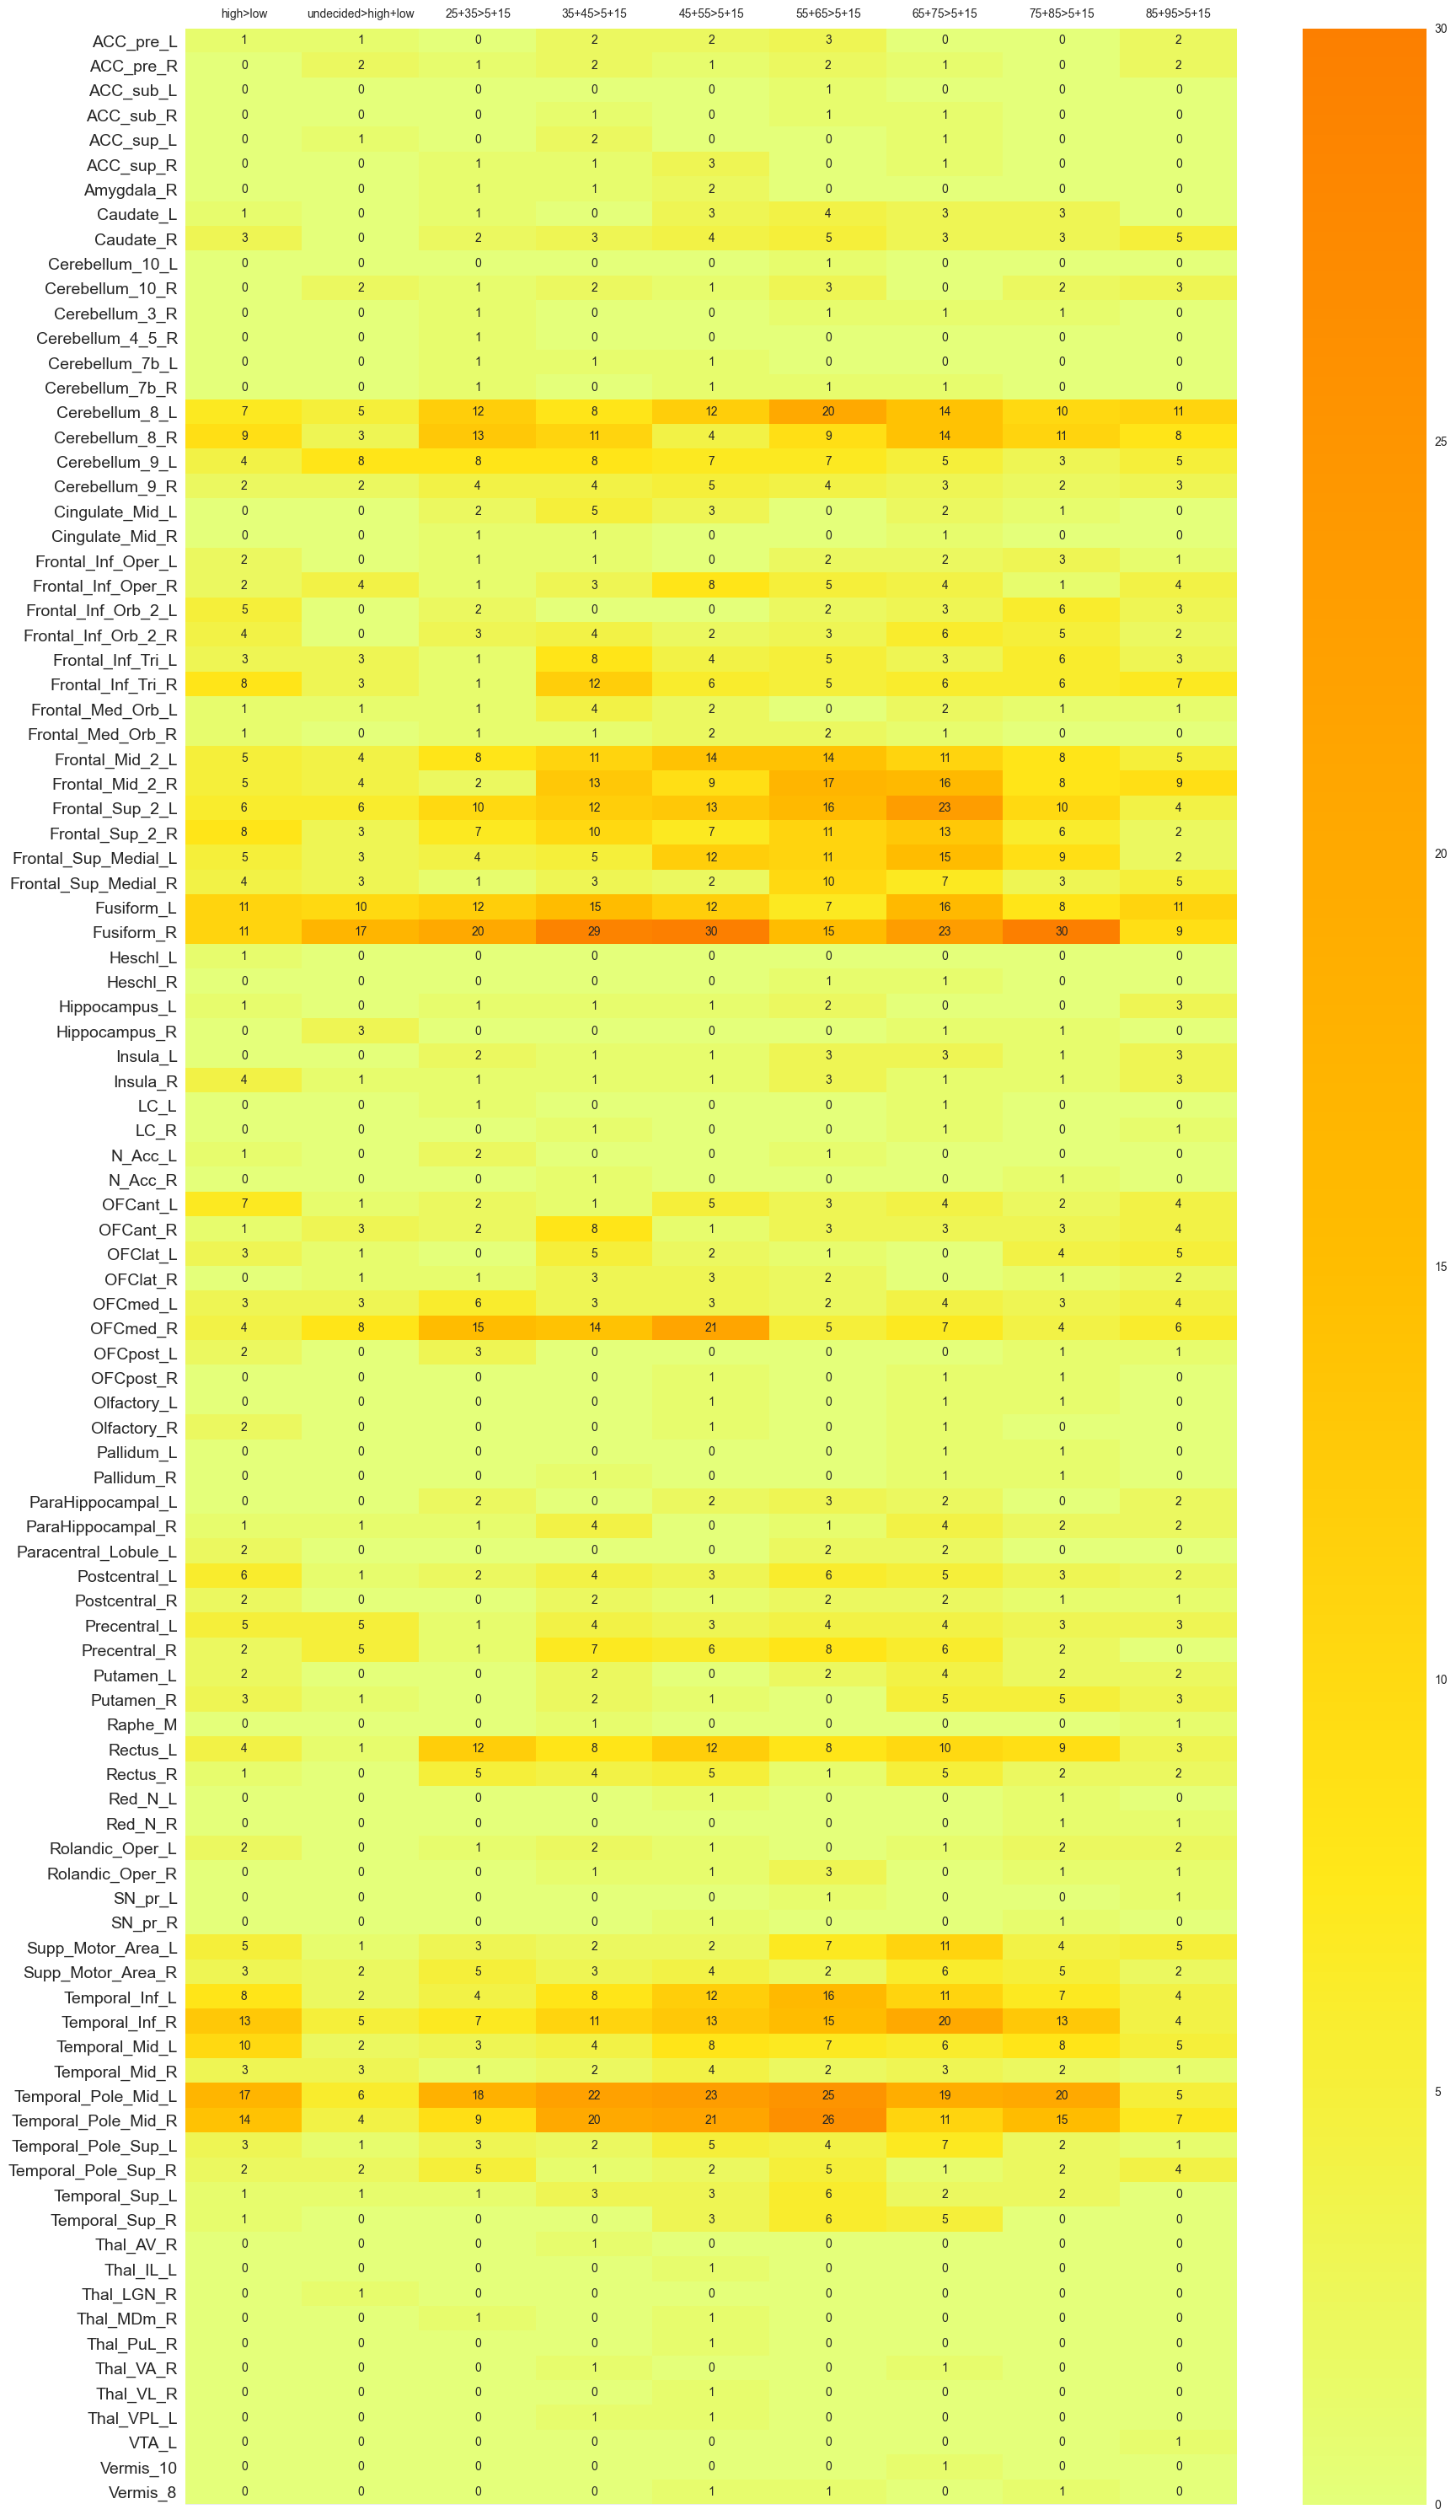

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(18, 30))
im = ax.imshow(mni_summary.values, cmap='Wistia', aspect='auto')

ax.set_xticks(range(len(mni_summary.columns)))
ax.set_yticks(range(len(mni_summary)))
ax.set_xticklabels(mni_summary.columns, fontsize=10)
ax.set_yticklabels(mni_summary.index, fontsize=14)

ax.xaxis.tick_top()

for i in range(len(mni_summary.index)):
    for j in range(len(mni_summary.columns)):
        ax.text(j, i, f'{mni_summary.values[i, j]:.0f}',
                ha='center', va='center', fontsize=10)

ax.grid(False)
ax.tick_params(which='both', length=0)

plt.colorbar(im)
plt.tight_layout()
plt.show()